# Test CHSH inequality

#### See notes "Entanglement in action" by John Watrous at
https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/entanglement-in-action/chsh-game

### Import section

In [1]:
# General
import numpy as np
 
# Qiskit imports
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.circuit import Parameter
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit.visualization import plot_histogram

# Qiskit Runtime imports
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
 
# Plotting routines
import matplotlib.pyplot as plt
import matplotlib.ticker as tck

### Example of Quantum Circuit

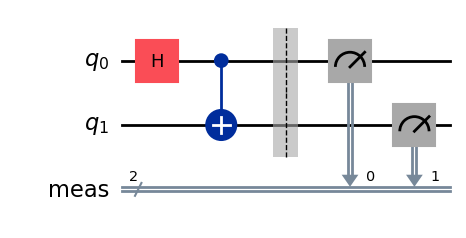

In [3]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

qc.draw(output="mpl", idle_wires=False, style="iqp")


{'11': 509, '00': 515}


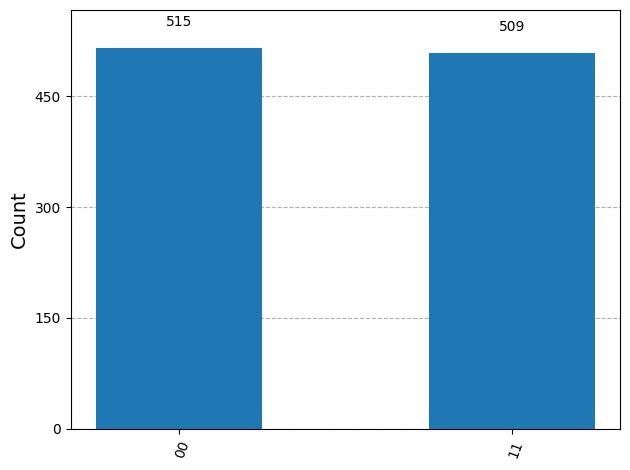

In [8]:
sampler = StatevectorSampler()
Nshots = 1024
result = sampler.run([qc], shots=Nshots).result()
print(result[0].data.meas.get_counts())

counts = result[0].data.meas.get_counts()
plot_histogram(counts)

## CHSH test

In [9]:
number_of_phases = 21
phases = np.linspace(0, 2 * np.pi, number_of_phases)

zz = np.zeros(number_of_phases)
xz = np.zeros(number_of_phases)
zx = np.zeros(number_of_phases)
xx = np.zeros(number_of_phases)

sampler = StatevectorSampler()
#simulator = AerSimulator()
Nshots = 1024

for ph in range(number_of_phases):

    ## ZZ measurement
    chsh_circuit = QuantumCircuit(2)
    chsh_circuit.h(0)
    chsh_circuit.cx(0, 1)
    chsh_circuit.ry(phases[ph], 0)
    chsh_circuit.measure_all()

    result = sampler.run([chsh_circuit], shots=1024).result()
 #   print(result[0].data.meas.get_counts())
    counts = result[0].data.meas.get_counts();
    
 #   job = simulator.run(chsh_circuit, shots=Nshots)
#    result = job.result()
#    counts = result.get_counts()

    if not '11' in counts: counts['11'] = 0
    if not '10' in counts: counts['10'] = 0
    if not '01' in counts: counts['01'] = 0
    if not '00' in counts: counts['00'] = 0
        
    zz[ph]=(counts['11']+counts['00']-counts['10']-counts['01'])/Nshots

    ## ZX measurement
    chsh_circuit2 = QuantumCircuit(2)
    chsh_circuit2.h(0)
    chsh_circuit2.cx(0, 1)
    chsh_circuit2.ry(phases[ph], 0)
    chsh_circuit2.h(1)
    chsh_circuit2.measure_all()

    result = sampler.run([chsh_circuit2], shots=1024).result()
#    print(result[0].data.meas.get_counts())
    counts = result[0].data.meas.get_counts();

#    job = simulator.run(chsh_circuit2, shots=Nshots)
#    result = job.result()
#    counts = result.get_counts()

    if not '11' in counts: counts['11'] = 0
    if not '10' in counts: counts['10'] = 0
    if not '01' in counts: counts['01'] = 0
    if not '00' in counts: counts['00'] = 0
        
    zx[ph]=(counts['11']+counts['00']-counts['10']-counts['01'])/Nshots

    ## XZ measurement
    chsh_circuit3 = QuantumCircuit(2)
    chsh_circuit3.h(0)
    chsh_circuit3.cx(0, 1)
    chsh_circuit3.ry(phases[ph], 0)
    chsh_circuit3.h(0)
    chsh_circuit3.measure_all()

    result = sampler.run([chsh_circuit3], shots=1024).result()
#    print(result[0].data.meas.get_counts())
    counts = result[0].data.meas.get_counts();

#    job = simulator.run(chsh_circuit3, shots=Nshots)
#    result = job.result()
#    counts = result.get_counts()
    
    if not '11' in counts: counts['11'] = 0
    if not '10' in counts: counts['10'] = 0
    if not '01' in counts: counts['01'] = 0
    if not '00' in counts: counts['00'] = 0
        
    xz[ph]=(counts['11']+counts['00']-counts['10']-counts['01'])/Nshots

    
    ## XX measurement
    chsh_circuit4 = QuantumCircuit(2)
    chsh_circuit4.h(0)
    chsh_circuit4.cx(0, 1)
    chsh_circuit4.ry(phases[ph], 0)
    chsh_circuit4.h(0)
    chsh_circuit4.h(1)
    chsh_circuit4.measure_all()

    result = sampler.run([chsh_circuit4], shots=1024).result()
 #   print(result[0].data.meas.get_counts())
    counts = result[0].data.meas.get_counts();

#    job = simulator.run(chsh_circuit4, shots=Nshots)
#    result = job.result()
#    counts = result.get_counts()

    if not '11' in counts: counts['11'] = 0
    if not '10' in counts: counts['10'] = 0
    if not '01' in counts: counts['01'] = 0
    if not '00' in counts: counts['00'] = 0
        
    xx[ph]=(counts['11']+counts['00']-counts['10']-counts['01'])/Nshots ;

chsh1_est = zz + xz - zx + xx;
chsh2_est = zz - xz + zx + xx;


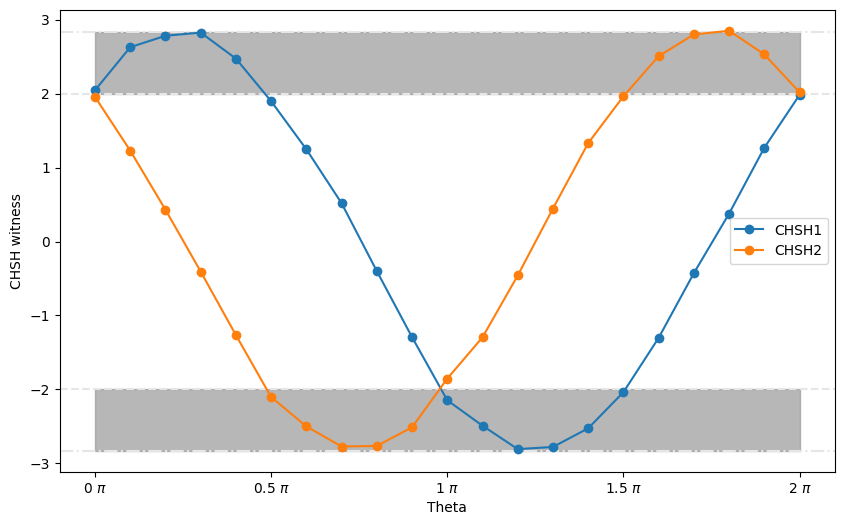

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

# results from hardware
ax.plot(phases / np.pi, chsh1_est, "o-", label="CHSH1", zorder=3)
ax.plot(phases / np.pi, chsh2_est, "o-", label="CHSH2", zorder=3)

# classical bound +-2
ax.axhline(y=2, color="0.9", linestyle="--")
ax.axhline(y=-2, color="0.9", linestyle="--")

# quantum bound, +-2√2
ax.axhline(y=np.sqrt(2) * 2, color="0.9", linestyle="-.")
ax.axhline(y=-np.sqrt(2) * 2, color="0.9", linestyle="-.")
ax.fill_between(phases / np.pi, 2, 2 * np.sqrt(2), color="0.6", alpha=0.7)
ax.fill_between(phases / np.pi, -2, -2 * np.sqrt(2), color="0.6", alpha=0.7)

# set x tick labels to the unit of pi
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
ax.xaxis.set_major_locator(tck.MultipleLocator(base=0.5))

# set labels, and legend
plt.xlabel("Theta")
plt.ylabel("CHSH witness")
plt.legend()
plt.show()

### Let's try on the real hardware

In [11]:
# Sostituisci 'IL_TUO_API_TOKEN' con il token reale copiato dalla dashboard
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform", 
    token="wfEHJFGlur25cWBX4fdE0468cOfFfVxSVSlubtbf_00e", 
    overwrite=True, 
    set_as_default=True
)

In [12]:
# To run on hardware, select the backend with the fewest number of jobs in the queue
service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
backend.name

qiskit_runtime_service.__init__:WARNING:2026-04-14 09:12:24,509: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-14 09:12:25,158: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-14 09:12:27,929: Using instance: open-instance, plan: open


'ibm_fez'